**🍫 Chocolate Sales Dataset (2023–2024)**
This dataset contains synthetic retail transaction data for chocolate sales across multiple stores, customers, and products during the years 2023–2024.

I have downloaded this from Kaggle. I intend to begin exploring. 

Basic Question in data analysis is one that seeks to address the fundamental aspect of the data. This type of question helps you identify and gather the necessary data to find answers and make informed decisions.

For a sales dataset, common EDA questions are:

**Which products sell the most?
Which months have the highest sales?
Which regions or countries perform best?
What is the relationship between quantity sold and revenue?
Are there any unusual spikes or drops?**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Importing the dataset**

In [5]:
 import os
os.chdir(r"C:\Users\arivu\Documents\My Manager\Portfolio\chocolate_eda\data")

sales = pd.read_csv('sales.csv')

Preview the data

In [6]:
sales.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


Sales data columns are:

order_id
order_date
product_id
store_id
customer_id
quantity
unit_price
discount
revenue
cost
profit

👉 **Which of these columns are numerical and which are categorical (labels/IDs)?**

In [8]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  object 
 1   order_date   1000000 non-null  object 
 2   product_id   1000000 non-null  object 
 3   store_id     1000000 non-null  object 
 4   customer_id  1000000 non-null  object 
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 83.9+ MB


👉 order_date is of type object (text), not a datetime.

If order_date stays as text, I can’t properly:

group by month
analyze trends over time
extract year, month, etc.

So this is my first real data cleaning step.

In [9]:
sales['order_date'] = pd.to_datetime(sales['order_date'])

Now that I have converted the order date to a datetime.. 

In [10]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 83.9+ MB


**Checking for null values**

In [11]:
sales.isnull().sum()

order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64

There are no null values, the dataset.

👉 In the current sales data, there are product names or just product IDs. To get meaningful insights, I should bring in the products dataset.


In [13]:
products = pd.read_csv('products.csv')

Preview the data

In [14]:
products.head()

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


Always safe to check for data types to avoid surprises later on.

In [15]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


Perfect — this is where things start getting interesting 🚀

From sales:

product_id (but no product name)

From products:

product_id ✅
product_name
brand
category
etc.

Its good to merge the two datasets so that:

each sales row also includes product details like name, brand, category

product_id ✅

That’s the common key to merge sales and products

In [16]:
sales_with_products = pd.merge(sales, products, on='product_id')

Let’s break it:

pd.merge(...) → combining two tables
sales → left table
products → right table
on='product_id' → match rows where product_id is the same


In [17]:
sales_with_products.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70,200
1,0RD00000056,2024-11-28,P0080,S090,C040441,4,5.28,0.00,21.12,12.92,8.20,Praline Chocolate 70%,Hershey,White,70,200
2,0RD00000118,2024-12-10,P0080,S042,C037981,5,11.69,0.00,58.45,34.78,23.67,Praline Chocolate 70%,Hershey,White,70,200
3,0RD00000262,2023-07-17,P0080,S087,C021100,3,4.77,0.15,12.16,6.67,5.50,Praline Chocolate 70%,Hershey,White,70,200
4,0RD00000337,2024-12-30,P0080,S098,C033992,3,4.61,0.10,12.45,7.37,5.08,Praline Chocolate 70%,Hershey,White,70,200


So now this data is meaningful enough to answer:

“Which products generate the most sales?”

👉 If I want to find top-selling products, what should I do?

Do I need to group data?
By which column?
What value am I aggregating?

From the columns:

order_id
product_id
quantity

👉 This suggests:

Each row = one product within an order, with its own quantity

So let’s answer the question

“Does each order_id have a quantity?”

👉 Not exactly.

Better way to say it:

An order_id can appear multiple times
Each row has a quantity for that specific product in that order
Connecting this to my goal

I want:

“top-selling products”

👉 What makes more sense to measure?

A) number of orders
B) total quantity sold
C) total revenue

Best option is to go by sum of quantity sold.

In [107]:
top_products = sales_with_products.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(5)

Simple bar chart:

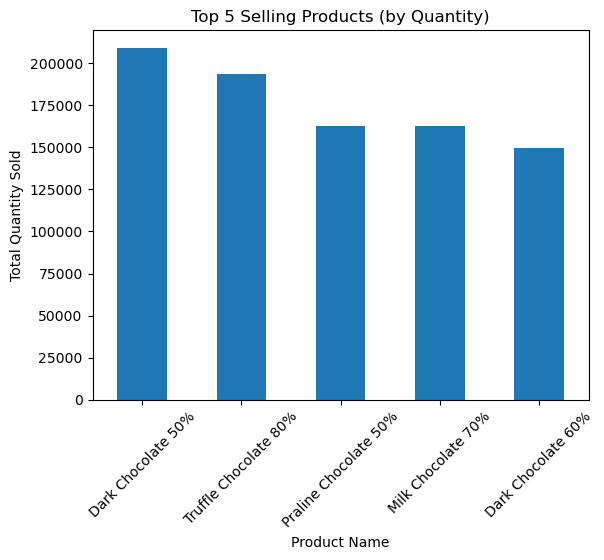

In [108]:
top_products.plot(kind='bar')
plt.title('Top 5 Selling Products (by Quantity)')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

Answer to the first Fundamental question 'Which product sells the most?' is **Dark Chocolate 50%**

With that lets get to the second Fundamental Question 'Which months have the highest sales?'

Though I could play a little with the Order Date, I would like to explore the Calendar dataset provided in Kaggle.

Load the calendar dataset:



In [25]:
calendar = pd.read_csv('calendar.csv')

Explore it

In [26]:
calendar.head()

,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [27]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         731 non-null    object
 1   year         731 non-null    int64 
 2   month        731 non-null    int64 
 3   day          731 non-null    int64 
 4   week         731 non-null    int64 
 5   day_of_week  731 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 34.4+ KB


I need to convert date object into datetime object to proced further

In [29]:
calendar['date'] = pd.to_datetime(calendar['date'])
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         731 non-null    datetime64[ns]
 1   year         731 non-null    int64         
 2   month        731 non-null    int64         
 3   day          731 non-null    int64         
 4   week         731 non-null    int64         
 5   day_of_week  731 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 34.4 KB


In [30]:
sales_with_calendar = pd.merge(
    sales,
    calendar,
    left_on='order_date',
    right_on='date'
)

Investigated the merged dataframes

In [31]:
sales_with_calendar.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000000 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
 11  date         1000000 non-null  datetime64[ns]
 12  year         1000000 non-null  int64         
 13  month        1000000 non-null  int64         
 14  day          1000000 non-null  int64         
 15  week         100

👉 “Group by ______ and calculate total ______”

In [32]:
monthly_sales = (
    sales_with_calendar
    .groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
)

I need to factor in the year to differentiate the months of each year

In [33]:
monthly_sales = monthly_sales.sort_values(['year', 'month'])

Plotting the same 

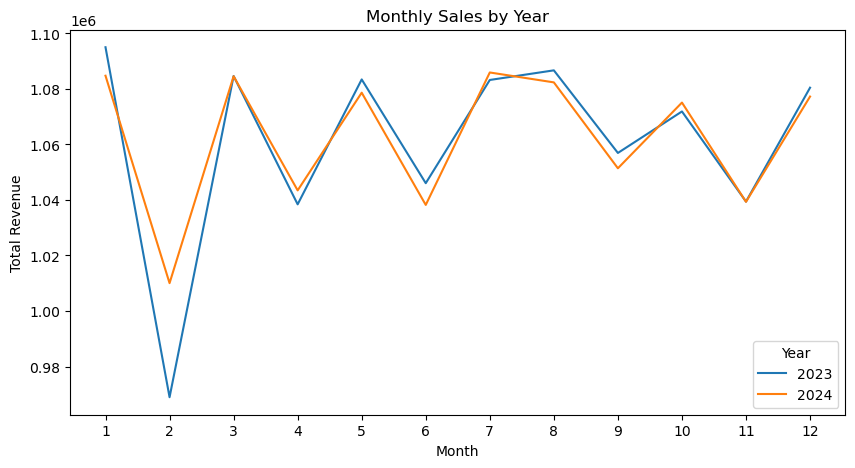

In [35]:
plt.figure(figsize=(10,5))

for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(data['month'], data['revenue'], label=year)

plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.legend(title='Year')
plt.xticks(range(1,13))
plt.show()

I am unhappy with months shown by its number. Lets categorize them properly using their month names.

In [36]:
monthly_sales['month_name'] = pd.to_datetime(monthly_sales['month'], format='%m').dt.strftime('%b')

That did the trick

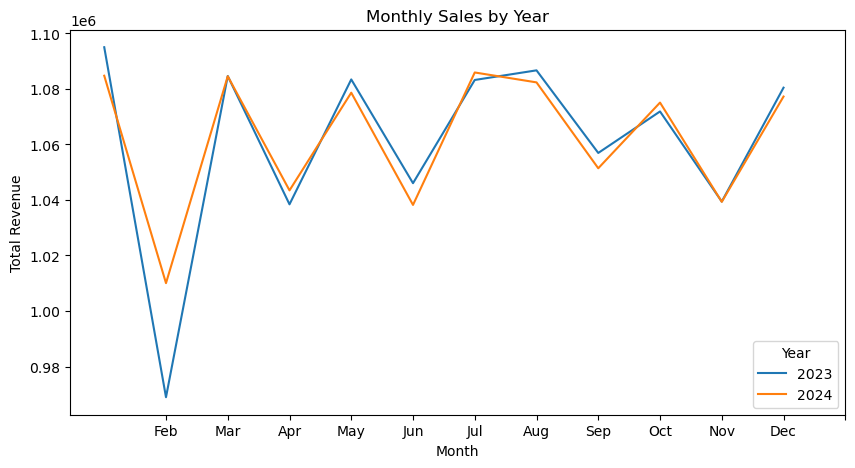

In [38]:
plt.figure(figsize=(10,5))

for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(data['month_name'], data['revenue'], label=year)

plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.legend(title='Year')
plt.xticks(range(1,13))
plt.show()

The plot shows January of 2023 to be the month that generated max revenue. But just to be clear...

In [40]:
The plot shows January of 2023 to be the month that generated max revenue. But just to be clear...

Now to confirm ...

In [42]:
top_month[['year', 'month_name', 'revenue']]

,year,month_name,revenue
0,2023,Jan,1095019.2


Answer to the second Fundamental Question 'Which months have the highest sales?' **January 2023**

The third fundamental question is **Which regions or countries perform best?**

There is a stores dataset. Lets first explore the dataset before merging it our sales dataset.


In [44]:
stores = pd.read_csv('stores.csv')

stores.head()

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


Merge the datasets using common column in this case it is store_id. 

It is a straight forward merge as the column names are not different in both datasets.

In [45]:
sales_with_stores = pd.merge(
    sales,
    stores,
    on='store_id'
)

Group by country

In [48]:
country_sales = (
    sales_with_stores
    .groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
)

Viewing the top country

In [49]:
top_country = country_sales.head(1)
print(top_country)

country
Canada    5085319.05
Name: revenue, dtype: float64


Group by City

In [50]:
city_sales = (
    sales_with_stores
    .groupby('city')['revenue']
    .sum()
    .sort_values(ascending=False)
)

Viewing the top city

In [51]:
top_city = city_sales.head(1)
print(top_city)

city
Toronto    4593793.59
Name: revenue, dtype: float64


The answer is third fundamental question **'Which regions or countries perform best?'** is Toronto city of Canada

Moving on the fourth fundamental question.. 'What is the relationship between quantity sold and revenue?'

Lets dig deep into relationship between variables in a dataset.

To compare two numeric values I used a Colleration Matrix.


In [55]:
corr_matrix = sales[['quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit']].corr()

print(corr_matrix)

            quantity  unit_price  discount   revenue      cost    profit
quantity    1.000000    0.000137 -0.000147  0.733962  0.722677  0.709027
unit_price  0.000137    1.000000 -0.000639  0.599279  0.590022  0.578986
discount   -0.000147   -0.000639  1.000000 -0.127252 -0.125071 -0.123258
revenue     0.733962    0.599279 -0.127252  1.000000  0.984520  0.966183
cost        0.722677    0.590022 -0.125071  0.984520  1.000000  0.906032
profit      0.709027    0.578986 -0.123258  0.966183  0.906032  1.000000


And then the Heat map can be used to visually show the correlation between all variables.

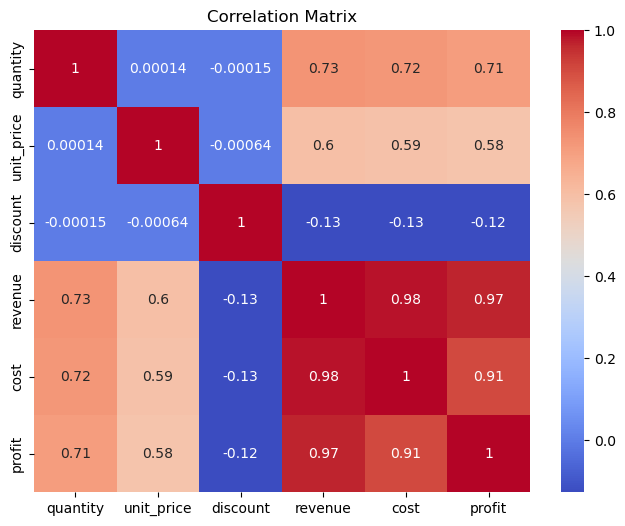

In [56]:


import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

📊 Correlation Matrix Summary

👉 The analysis reveals how different variables influence revenue and each other:

Quantity vs Revenue (0.73)
→ Strong positive relationship
→ Higher quantity sold generally leads to higher revenue
Unit Price vs Revenue (0.60)
→ Moderate positive relationship
→ Pricing plays an important role in revenue generation
Discount vs Revenue (-0.13)
→ Weak negative relationship
→ Discounts slightly reduce revenue but are not a major driver
Cost vs Revenue (0.98)
→ Very strong positive relationship
→ Indicates cost increases proportionally with sales volume
Profit vs Revenue (0.97)
→ Very strong positive relationship
→ Higher revenue directly leads to higher profit

In [53]:
sales['quantity'].corr(sales['revenue'])

0.733961518871672

Answer to the fourth question **'What is the relationship between quantity sold and revenue?'** is Strong positive relationship. Higher quantity sold generated higher revenue.

Key insight: **Revenue is primarily driven by quantity sold and unit price, while discounts have a minimal negative impact. Cost and profit are highly correlated with revenue due to their direct dependency on sales volume.**

Moving on the final question **Are there any unusual spikes or drops?**

Our monthly sales data already showcases this


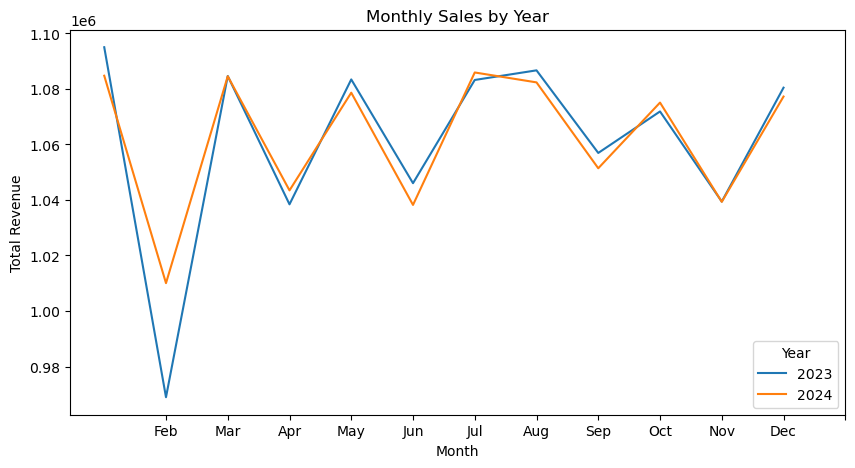

In [94]:
plt.figure(figsize=(10,5))

for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(data['month_name'], data['revenue'], label=year)

plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.legend(title='Year')
plt.xticks(range(1,13))
plt.show()

Are there sharp peaks in certain months?
Any sudden dips compared to neighboring months?
Or is the trend smooth and gradual?

February is the only month that shows a drastic dip. This is irrespective of the year.

We can better examine this trend using the customer dataset

Answer to the final Fundamental Question 'The monthly sales trend shows relatively stable performance across both 2023 and 2024, with only minor fluctuations. A noticeable dip occurs in February, followed by a consistent recovery in subsequent months. Overall, there are no extreme spikes or sharp declines, indicating steady demand with slight seasonal variation. The similar patterns across both years suggest consistent business performance over time'.

Lastly we can explore the customer dataset for any surprises. 

In [96]:
customers = pd.read_csv('customers.csv')

customers.head()

,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


This information can answer more questions ..

Who is buying?

First create a monthly customer count

In [99]:
customer_month = (
    sales_with_calendar
    .groupby(['year', 'month'])['customer_id']
    .nunique()
    .reset_index()
)

customer_month.rename(columns={'customer_id': 'customer_count'}, inplace=True)

customer_month.head()


,year,month,customer_count
0,2023,1,28895
1,2023,2,26681
2,2023,3,28693
3,2023,4,27897
4,2023,5,28726


Plot the Monthly customer count to display its secrets

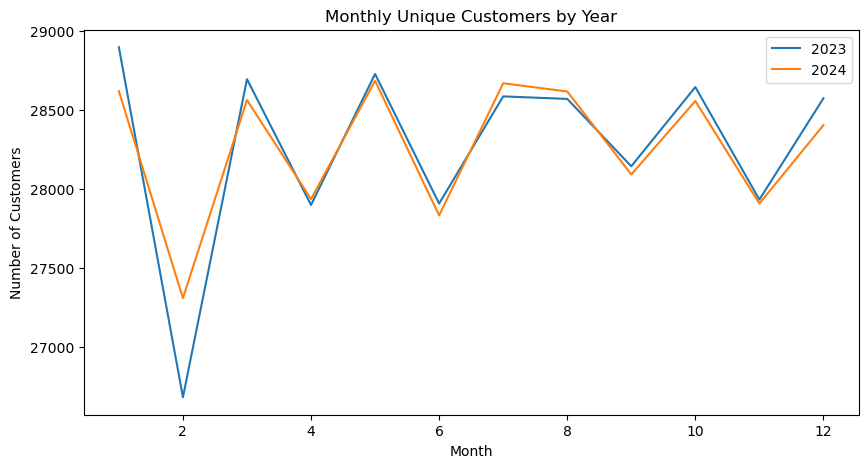

In [100]:
plt.figure(figsize=(10,5))

for year in customer_month['year'].unique():
    data = customer_month[customer_month['year'] == year]
    plt.plot(data['month'], data['customer_count'], label=year)

plt.title('Monthly Unique Customers by Year')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

👉 February shows a clear dip in both years

2023: sharp drop
2024: noticeable drop (less severe but still present)

👉 And importantly:

The pattern is consistent across both years

This confirms:

February has fewer unique customers

You now have:

✅ Customers ↓ in February
✅ Orders ↓ in February
➖ Quantity ↓ slightly
➖ Price ≈ same
➖ Discount ≈ same

Which type of customers dropped?

loyalty vs non-loyal?
new vs returning?
specific age group?

Merge customers with main dataset


In [101]:
sales_customers = pd.merge(
    sales_with_calendar,
    customers,
    on='customer_id'
)

Group by month + loyalty

In [102]:
customer_type_month = (
    sales_customers
    .groupby(['year', 'month', 'loyalty_member'])['customer_id']
    .nunique()
    .reset_index()
)

customer_type_month.rename(columns={'customer_id': 'customer_count'}, inplace=True)

Filter February

In [103]:
feb_loyalty = customer_type_month[customer_type_month['month'] == 2]
print(feb_loyalty)

    year  month  loyalty_member  customer_count
2   2023      2               0           13281
3   2023      2               1           13400
26  2024      2               0           13551
27  2024      2               1           13757


Plot (VERY IMPORTANT)

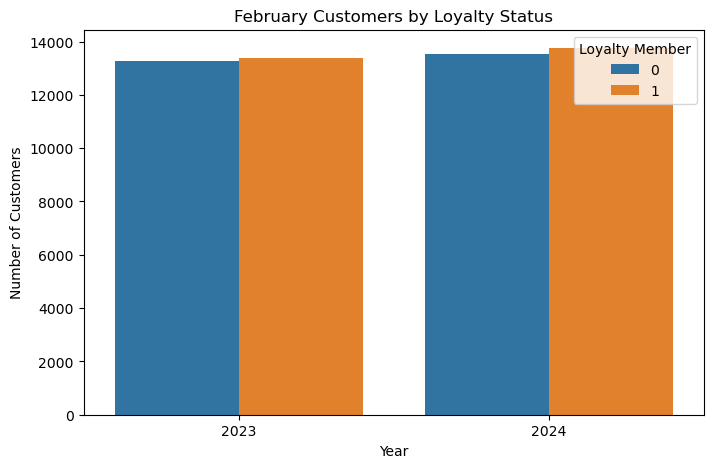

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=feb_loyalty,
    x='year',
    y='customer_count',
    hue='loyalty_member'
)

plt.title('February Customers by Loyalty Status')
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.legend(title='Loyalty Member')
plt.show()

The decline in February sales is not explained by internal factors such as pricing, discounting, or customer segmentation. This suggests that external factors—such as seasonal demand shifts or increased market competition—may be influencing customer purchasing behavior

Since the February decline is consistent across customer segments and not driven by pricing or promotional changes, it likely reflects broader external influences such as seasonal demand patterns or competitive market dynamics.